**Part A: 1. Represent the System in Matrix Form**

In [1]:
import numpy as np

# Define the coefficient matrix A
A = np.array([
    [2, -1, 1, 0],
    [1, 1, 0, 1],
    [-1, 0, 3, -1],
    [0, 1, 1, 1]
])

# Define the constant vector b
b = np.array([150, 420, 100, 380])

print("Coefficient Matrix A:")
print(A)
print("\nConstant Vector b:")
print(b)

Coefficient Matrix A:
[[ 2 -1  1  0]
 [ 1  1  0  1]
 [-1  0  3 -1]
 [ 0  1  1  1]]

Constant Vector b:
[150 420 100 380]


In [2]:
# Solve the system of equations Ax = b
x = np.linalg.solve(A, b)

print("Solution for traffic flows (vehicles per 10 minutes):")
print(f"x1 = {x[0]:.2f}")
print(f"x2 = {x[1]:.2f}")
print(f"x3 = {x[2]:.2f}")
print(f"x4 = {x[3]:.2f}")

Solution for traffic flows (vehicles per 10 minutes):
x1 = 138.33
x2 = 225.00
x3 = 98.33
x4 = 56.67


**Part B: Calculus Analysis of Vehicle Speed and Acceleration**

In [3]:
import sympy

# Define the symbolic variable t
t = sympy.Symbol('t')

# Define the velocity function v(t)
v_t = 70 + 12 * sympy.cos(sympy.pi * t / 5) - 4 * sympy.sin(2 * sympy.pi * t / 5)

print(f"Velocity function v(t): {v_t}")

# Calculate the acceleration function a(t) by differentiating v(t) with respect to t
a_t = sympy.diff(v_t, t)

print(f"Acceleration function a(t): {a_t}")

Velocity function v(t): -4*sin(2*pi*t/5) + 12*cos(pi*t/5) + 70
Acceleration function a(t): -12*pi*sin(pi*t/5)/5 - 8*pi*cos(2*pi*t/5)/5


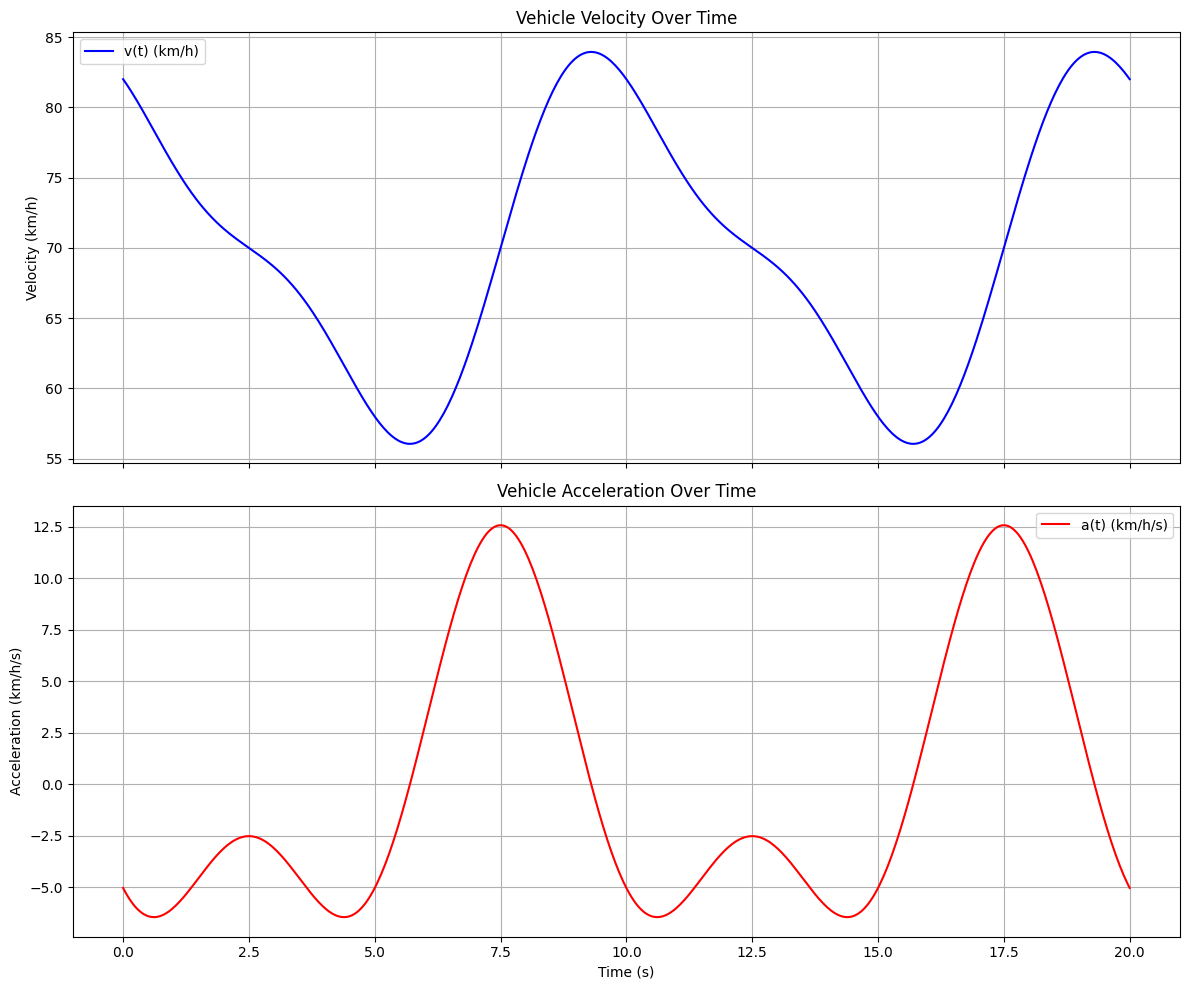

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Convert sympy expressions to numerical functions
v_func = sympy.lambdify(t, v_t, 'numpy')
a_func = sympy.lambdify(t, a_t, 'numpy')

# Define a time range for plotting
t_values = np.linspace(0, 20, 500) # Plotting over 20 seconds, representing a few cycles

# Calculate velocity and acceleration values
v_values = v_func(t_values)
a_values = a_func(t_values)

# Plotting
fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot Velocity
axes[0].plot(t_values, v_values, label='v(t) (km/h)', color='blue')
axes[0].set_title('Vehicle Velocity Over Time')
axes[0].set_ylabel('Velocity (km/h)')
axes[0].grid(True)
axes[0].legend()

# Plot Acceleration
axes[1].plot(t_values, a_values, label='a(t) (km/h/s)', color='red')
axes[1].set_title('Vehicle Acceleration Over Time')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Acceleration (km/h/s)')
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# Find zero crossings of acceleration function (where a(t) = 0)
from scipy.optimize import brentq
import numpy as np

a_func_num = lambda t: -7.5398 * np.sin(np.pi * t / 5) - 5.0265 * np.cos(2 * np.pi * t / 5)

# Find zero crossings in first period (0 to 10 seconds)
zero_crossings = []
t_search = np.linspace(0, 10, 1000)
for i in range(len(t_search) - 1):
    if a_func_num(t_search[i]) * a_func_num(t_search[i+1]) < 0:
        root = brentq(a_func_num, t_search[i], t_search[i+1])
        zero_crossings.append(round(root, 3))

print("Times where acceleration = 0 (transition points):")
for t_val in zero_crossings:
    print(f"t = {t_val} seconds")

Times where acceleration = 0 (transition points):
t = 5.699 seconds
t = 9.301 seconds


**Part C: Probability Analysis of Autonomous Vehicle Reaction Times**

In [5]:
from scipy.stats import norm
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters of the normal distribution
mu = 0.85  # Mean reaction time in seconds
sigma = 0.25 # Standard deviation in seconds

# Create a normal distribution object
dist = norm(loc=mu, scale=sigma)

print(f"Normal Distribution Parameters: Mean (μ) = {mu} s, Standard Deviation (σ) = {sigma} s")

Normal Distribution Parameters: Mean (μ) = 0.85 s, Standard Deviation (σ) = 0.25 s


In [6]:
# Probability of a rapid reaction (e.g., less than 0.5 seconds)
rapid_reaction_threshold = 0.5
prob_rapid = dist.cdf(rapid_reaction_threshold)
print(f"Probability of reaction time < {rapid_reaction_threshold} s (rapid reaction): {prob_rapid:.4f}")

# Probability of a delayed reaction (e.g., greater than 1.5 seconds)
delayed_reaction_threshold = 1.5
prob_delayed = 1 - dist.cdf(delayed_reaction_threshold)
print(f"Probability of reaction time > {delayed_reaction_threshold} s (delayed reaction): {prob_delayed:.4f}")

# Probability of a very delayed reaction (e.g., greater than 2 seconds)
very_delayed_reaction_threshold = 2.0
prob_very_delayed = 1 - dist.cdf(very_delayed_reaction_threshold)
print(f"Probability of reaction time > {very_delayed_reaction_threshold} s (very delayed reaction): {prob_very_delayed:.4f}")

Probability of reaction time < 0.5 s (rapid reaction): 0.0808
Probability of reaction time > 1.5 s (delayed reaction): 0.0047
Probability of reaction time > 2.0 s (very delayed reaction): 0.0000


In [7]:
# Calculate various percentile values
pct_5 = dist.ppf(0.05)
pct_50 = mu  # For a normal distribution, the 50th percentile (median) is equal to the mean
pct_95 = dist.ppf(0.95)
pct_99 = dist.ppf(0.99)

print(f"5th percentile reaction time: {pct_5:.3f} s (95% of reactions are slower)")
print(f"50th percentile (median) reaction time: {pct_50:.3f} s")
print(f"95th percentile reaction time: {pct_95:.3f} s (95% of reactions are faster)")
print(f"99th percentile reaction time: {pct_99:.3f} s (99% of reactions are faster)")

5th percentile reaction time: 0.439 s (95% of reactions are slower)
50th percentile (median) reaction time: 0.850 s
95th percentile reaction time: 1.261 s (95% of reactions are faster)
99th percentile reaction time: 1.432 s (99% of reactions are faster)


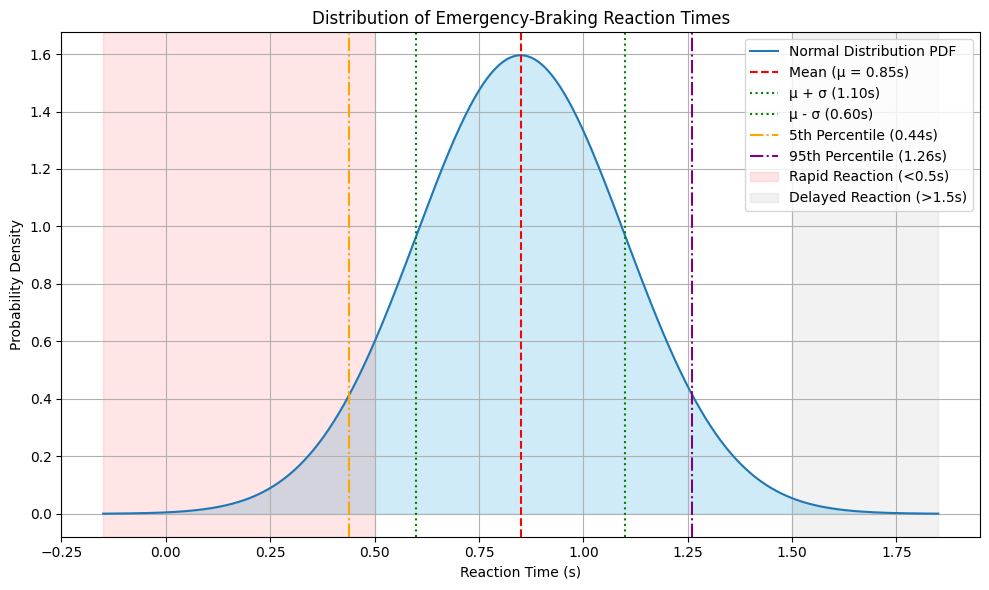

In [8]:
x_values = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)
y_values = dist.pdf(x_values)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_values, y_values, label='Normal Distribution PDF')
ax.fill_between(x_values, 0, y_values, color='skyblue', alpha=0.4)

# Mark mean and standard deviations
ax.axvline(mu, color='red', linestyle='--', label=f'Mean (μ = {mu}s)')
ax.axvline(mu + sigma, color='green', linestyle=':', label=f'μ + σ ({mu+sigma:.2f}s)')
ax.axvline(mu - sigma, color='green', linestyle=':', label=f'μ - σ ({mu-sigma:.2f}s)')

# Mark percentiles
ax.axvline(pct_5, color='orange', linestyle='-.', label=f'5th Percentile ({pct_5:.2f}s)')
ax.axvline(pct_95, color='purple', linestyle='-.', label=f'95th Percentile ({pct_95:.2f}s)')

# Mark rapid and delayed reaction thresholds
ax.axvspan(x_values.min(), rapid_reaction_threshold, color='red', alpha=0.1, label='Rapid Reaction (<0.5s)')
ax.axvspan(delayed_reaction_threshold, x_values.max(), color='grey', alpha=0.1, label='Delayed Reaction (>1.5s)')

ax.set_title('Distribution of Emergency-Braking Reaction Times')
ax.set_xlabel('Reaction Time (s)')
ax.set_ylabel('Probability Density')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

**Part D: Statistical Analysis of ISA Speed Compliance**

In [9]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd

# Observed vehicle speeds (km/h)
speeds = np.array([49, 52, 55, 48, 50, 53, 57, 51, 54, 49, 52, 56])
legal_speed_limit = 50 # km/h

print(f"Observed speeds: {speeds}")
print(f"Legal speed limit: {legal_speed_limit} km/h")

Observed speeds: [49 52 55 48 50 53 57 51 54 49 52 56]
Legal speed limit: 50 km/h


In [10]:
# Calculate descriptive statistics
mean_speed = np.mean(speeds)
median_speed = np.median(speeds)
std_dev_speed = np.std(speeds, ddof=1) # ddof=1 for sample standard deviation

print(f"Mean Observed Speed: {mean_speed:.2f} km/h")
print(f"Median Observed Speed: {median_speed:.2f} km/h")
print(f"Standard Deviation of Observed Speeds: {std_dev_speed:.2f} km/h")

Mean Observed Speed: 52.17 km/h
Median Observed Speed: 52.00 km/h
Standard Deviation of Observed Speeds: 2.92 km/h


Hypothesis Testing: If the mean observed speed is significantly different from the legal speed limit of 50 km/h.

Null Hypothesis (H0): The true mean speed in the trial zone is equal to 50 km/h.
Alternative Hypothesis (H1): The true mean speed in the trial zone is greater than 50 km/h (since we are concerned with exceeding the limit), will be using a significance level of 0.05.

In [11]:
# Perform one-sample t-test
t_statistic, p_value = stats.ttest_1samp(speeds, legal_speed_limit, alternative='greater')

alpha = 0.05

print(f"T-statistic: {t_statistic:.3f}")
print(f"P-value (one-sided, greater): {p_value:.3f}")

if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.3f}) is less than the significance level ({alpha}), we reject the null hypothesis.")
    print("Conclusion: The mean observed speed is significantly greater than 50 km/h.")
else:
    print(f"\nSince the p-value ({p_value:.3f}) is greater than the significance level ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant evidence to suggest the mean observed speed is greater than 50 km/h.")

T-statistic: 2.572
P-value (one-sided, greater): 0.013

Since the p-value (0.013) is less than the significance level (0.05), we reject the null hypothesis.
Conclusion: The mean observed speed is significantly greater than 50 km/h.


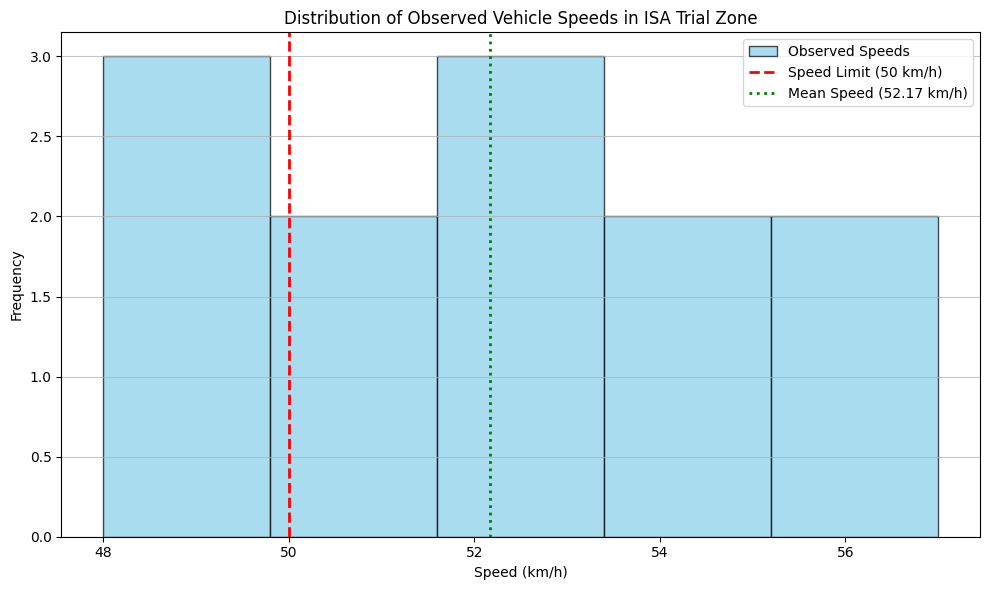

In [12]:
# Create a histogram of observed speeds
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(speeds, bins=5, edgecolor='black', alpha=0.7, color='skyblue', label='Observed Speeds')
ax.axvline(legal_speed_limit, color='red', linestyle='--', linewidth=2, label=f'Speed Limit ({legal_speed_limit} km/h)')
ax.axvline(mean_speed, color='green', linestyle=':', linewidth=2, label=f'Mean Speed ({mean_speed:.2f} km/h)')

ax.set_title('Distribution of Observed Vehicle Speeds in ISA Trial Zone')
ax.set_xlabel('Speed (km/h)')
ax.set_ylabel('Frequency')
ax.legend()
ax.grid(axis='y', alpha=0.75)
plt.tight_layout()
plt.show()